# Part IV: Images

**"A picture is worth a thousand words."**

Colab slideshow based on:

1. `Part IV. Images (Introduction)`
2. `Chapter 8. Digital Images Representation`

## Part IV: Images — Motivation

Images are used extensively in:

- biological research
- medical clinics
- microscopy
- automated identification of objects
- tracking cells and intracellular components
- phenotype identification by object properties

Images also require large volumes of storage, motivating compression and efficient analysis.

## Biological and medical image data

The explosion of biological and medical images comes from:

- improved microscopy technologies
- fluorescent labeling
- high-throughput microscopy systems
- cheaper storage devices
- stronger processors and machine-learning methods

The goal is to extract meaningful knowledge from image content.

## Image-related Python packages

The following packages are used in this part of the book:

The Python Imaging Library (PIL) is the main package used for image representation and manipulation.

```python
from PIL import Image
```

The Scientific Computing Library (scipy) contains many useful functions for image processing.

```python
from scipy.ndimage.measurements import label
```



# 8 Digital Images Representation

Computers store data as bits.

This chapter explains how colors and light intensities — that is, images — are represented using integers.

## 8.1 What Is a Digital Image?

A digital image is a discrete, numeric representation of a real image.

The image is divided into cells called **pixels**.

A digital image can be represented by an \(n \times m\) matrix \(M\), where each position stores numeric information about light intensity and color.

## Digital representation of an image

<img src="fig8.1.png" width="600">

**Figure 8.1** A digital representation of an image.

## RGB images

In RGB format, each pixel specifies three values:

- red
- green
- blue

Together, these three components determine the pixel color.

## RGB components

<img src="fig8.2.png" width="600">

**Figure 8.2** RGB components of an image.

## Gray-level images

In gray-level images, each pixel contains a single value:

- low value → dark pixel
- high value → bright pixel

In this chapter, we use standard **256 gray-level images**.

## 256 gray-level image

<img src="fig8.3.png" width="500">

**Figure 8.3** 256 gray-level image.

## Pixel resolution

Resolution is related to the physical size of a pixel.

For the same image area:

- higher resolution → smaller pixels
- lower resolution → larger pixels
- higher resolution reveals finer details

## Pixel resolution

<img src="fig8.4.png" width="650">

**Figure 8.4** Pixel resolution.

## Bit depth

Bit depth is the number of bits used to represent each pixel.

Examples:

- 1 bit per pixel → $2^1 = 2$ levels: black and white
- 8 bits per pixel → $2^8 = 256$ gray levels
- $k$ bits per pixel → $2^k$ gray levels

## Gray levels and black-white levels

<img src="fig8.5.png" width="600">

**Figure 8.5** (a) 256 gray levels (0–255) (b) Two gray levels (0–1).

## Higher-dimensional images

Images can have more than two dimensions.

Examples:

- video: sequence of 2D frames over time
- microscopy with multiple fluorescent markers
- medical 3D scans

The additional dimension may represent time, depth, or marker color.

## 3D image

<img src="fig8.6.png" width="600">

**Figure 8.6** 3D image.

## 3D image

<img src="fig8.6.1.png" width="600">

**Figure 8.6.1** 3D image.

## Memory requirements

A 1024 × 1024 gray-level image with 8 bit depth takes:

$
1024 \times 1024 \times 8 \text{ bits}
$

This equals:

$
2^{10} \times 2^{10} \times 2^3 = 2^{23} \text{ bits}
$

or:

$
2^{20} \text{ bytes} = 1 \text{ MB}
$

## Exercise 1

A one minute long video is made out of a sequence of 2D images captured every second.

Each image is of size 512 × 512 pixels and depth 12 bit/pixel.

How much memory does this video consume without compression?

## Compression

Compression converts an object \(A\) into an object \(B\) that consumes less memory.

Two main types:

- **lossless compression**: no information is lost
- lossless formats: `tiff, png, bmp, gif`

- **lossy compression**: some information may be lost
- lossy format:`jpg`



## JPEG compression intuition

JPEG partitions an image into 8 × 8 pixel squares.

Many such squares have gradual changes between neighboring pixels.

These changes can often be approximated using fewer bits, saving much storage space.

## Image compression

<img src="fig8.7.png" width="650">

**Figure 8.7** Image of Drosophila Kc167 cells. Left: original image. Right: highly compressed image in jpeg format. Three 8 × 8 pixel squares are shown.

## 8.2 Getting Started with PIL

PIL allows us to:

- open images
- show images
- rotate images
- save images
- crop regions
- convert image formats

In [6]:
from urllib.request import urlretrieve
from PIL import Image

url = "https://raw.githubusercontent.com/ariefouren/BIU-bio-python-2026/main/03_Chapters/08_Digital_Images_Representation/slides/fig8.3.png"

urlretrieve(url, "fig8.3.png") # retrieve the image from the URL and save it as fig8.3.png

im = Image.open("fig8.3.png")

print("format:", im.format)  # image format (PNG, JPEG, etc.)
print("size:", im.size)      # image size (width, height) in pixels

print("The original image:")
display(im)     # display the image in Jupyter Notebook

rot = im.rotate(45)     # rotate the image 45 degrees counterclockwise
print("The rotated image:")
display(rot)    # display the rotated image in Jupyter Notebook

im.save("my_image.png")  # save

region = im.crop((500, 500, 1000, 1000))  # crop the image as in Figure 8.8
print("The cropped region (500, 500, 1000, 1000):")
display(region)  # display the cropped region in Jupyter Notebook

format: PNG
size: (1328, 1184)


## Cropping an image in `PIL`

<img src="fig8.8.png" width="500">

**Figure 8.8** Cropping an image in PIL.

## Code explained

- `im` is an image object.
- `im.size` stores the width and height as a tuple.
- `show`, `rotate`, `save`, and `crop` are functions of image objects.

## Convert image to gray levels

Gray-level images use values from 0 to 255:

- 0 = black
- 255 = white

Use:

```python
im = im.convert('L')
```

Original image (color):


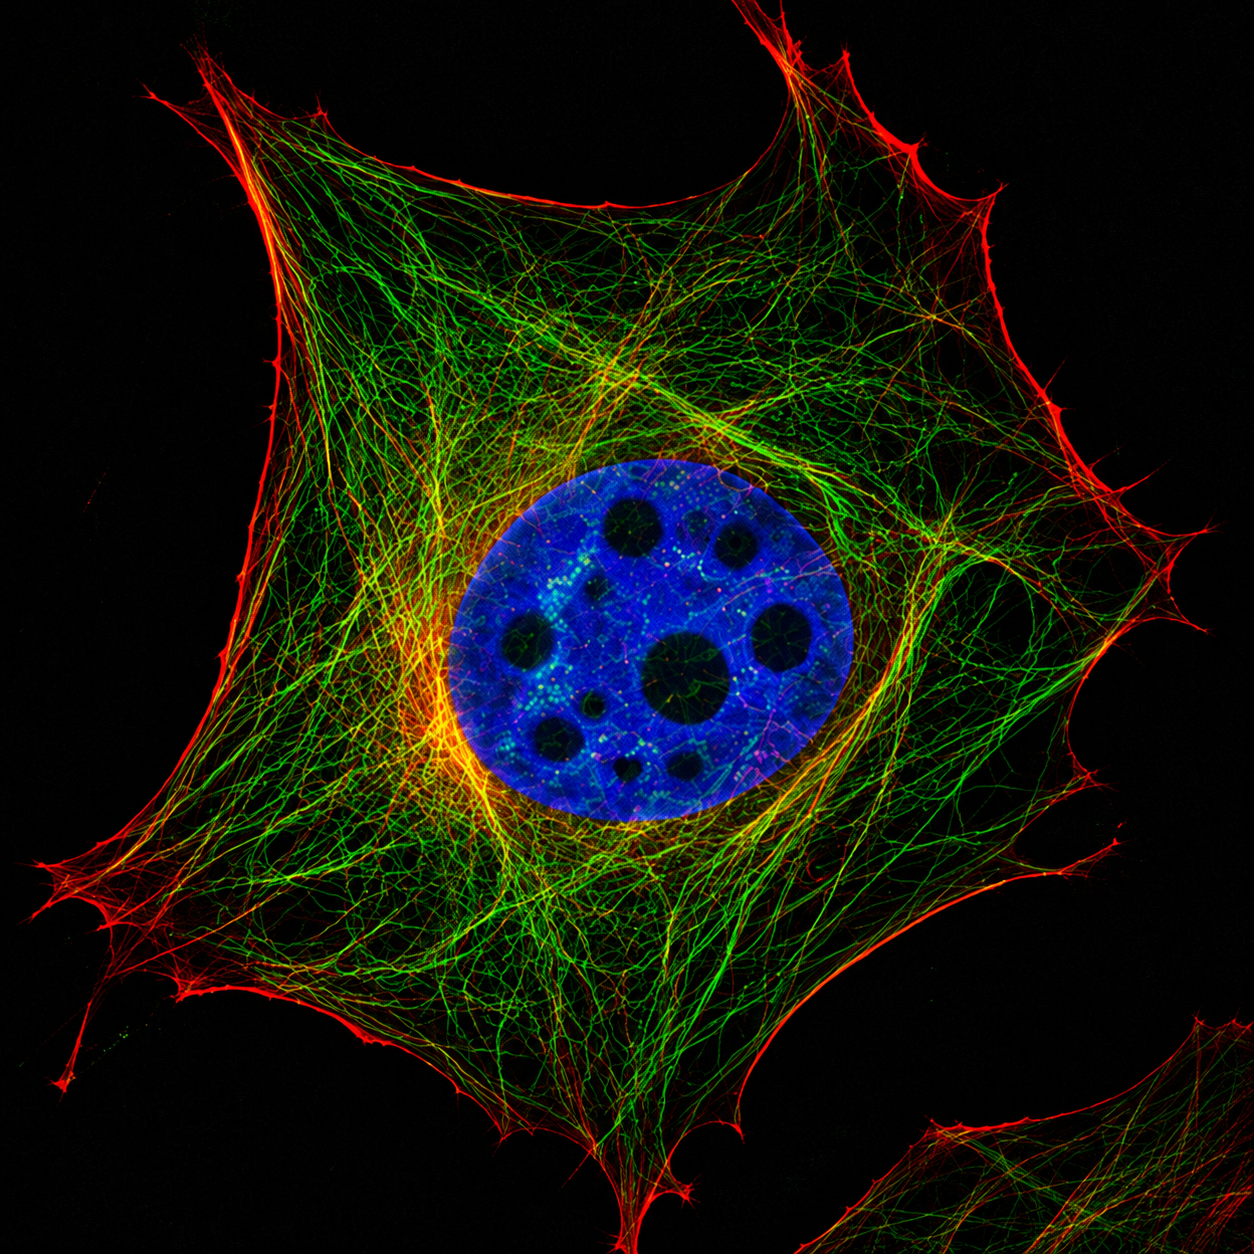

Image converted to 256 gray levels:


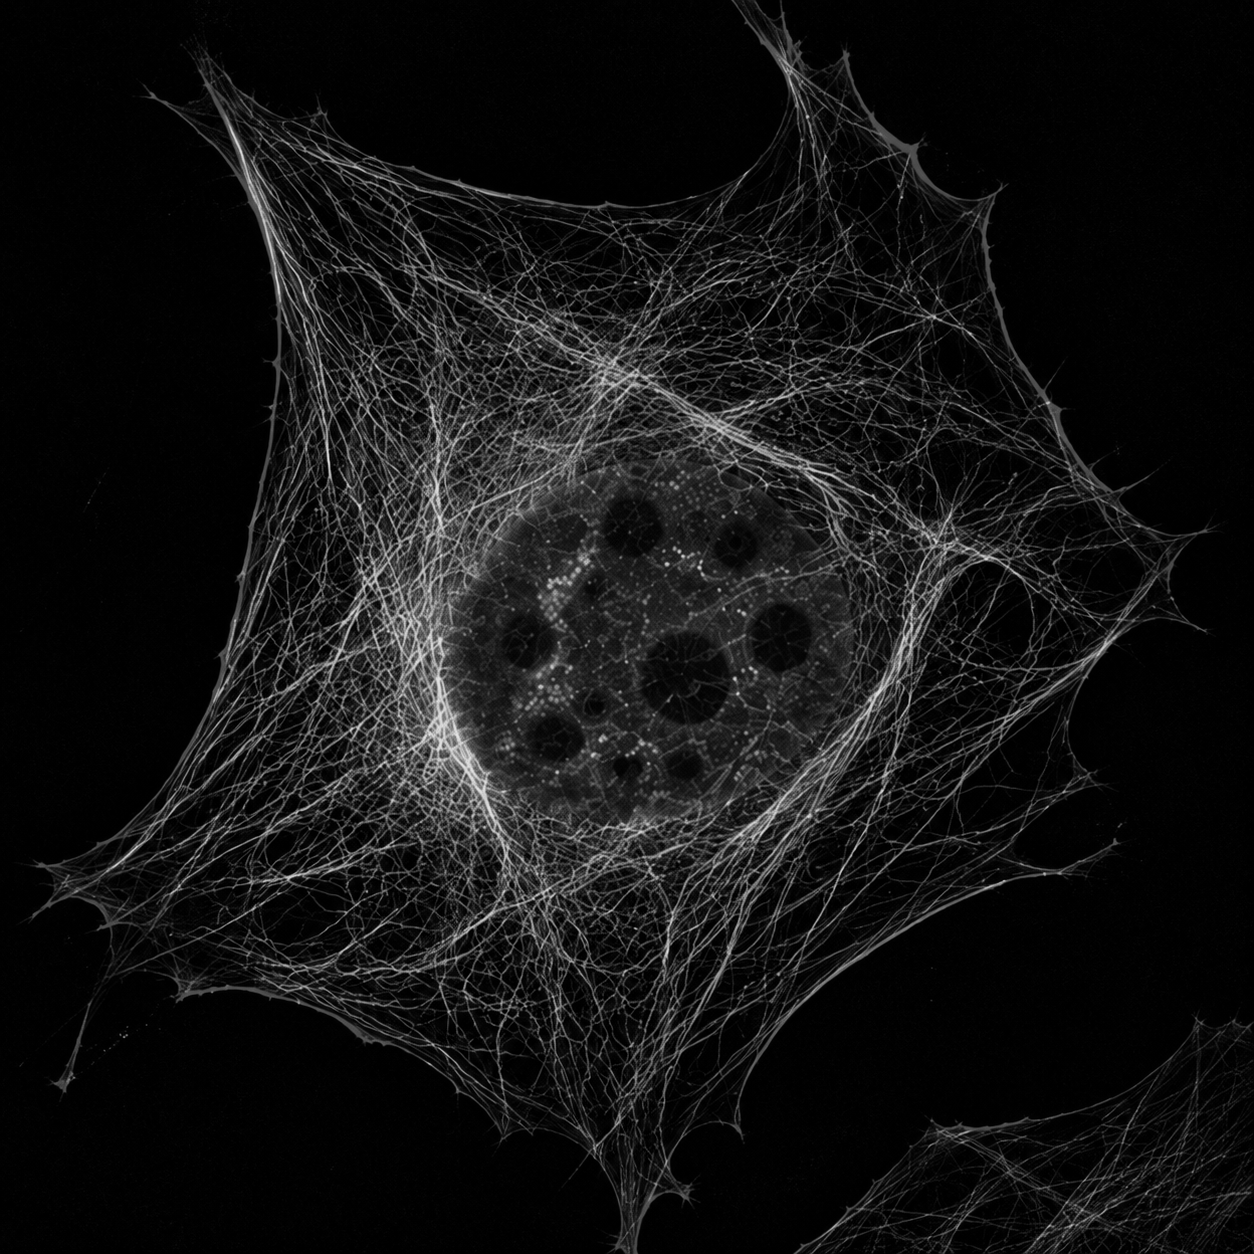

In [10]:
from urllib.request import urlretrieve
from PIL import Image

url = "https://raw.githubusercontent.com/ariefouren/BIU-bio-python-2026/main/03_Chapters/08_Digital_Images_Representation/slides/cell_color.png"

urlretrieve(url, "cell_color.png")

im = Image.open("cell_color.png")

print("Original image (color):")
display(im)    # display the original color image in Jupyter Notebook

gray_levels_im = im.convert('L')    # convert to 256 gray levels (0-255)
print("Image converted to 256 gray levels:")
display(gray_levels_im)    # display the image converted to 256 gray levels in Jupyter Notebook

## Gray-level pixels and values

<img src="fig8.9.png" width="650">

**Figure 8.9** (a) 10×10 pixels of 256 gray-level image (b) The corresponding pixel values.

## Exercise 2

Open a color image of your choice using:

```python
Image.open()
```

Then convert it into a 256 gray-level image and observe the result using:

```python
show()
```

## Exercise 3

In black and white images, black is represented by 0 and white by 1.

How do you think Python converts such images into 256 gray-level images?

## Accessing pixels

To analyze and manipulate an image, we need access to its pixels.

Use:

```python
mat = im.load()
```

Then access a pixel using:

```python
mat[x, y]
```

In [11]:
from PIL import Image
from urllib.request import urlretrieve

# Download the image from GitHub
url = "https://raw.githubusercontent.com/USERNAME/REPOSITORY/main/cell_color.png"
urlretrieve(url, "cell_color.png")

# Open the image and convert it to grayscale ('L')
im = Image.open("cell_color.png").convert('L')

# Access the pixel matrix
mat = im.load()

# Print the upper-left 10x10 block of pixel values
for y in range(10):
    for x in range(10):
        print(f"{mat[x, y]:3}", end=" ")
    print()

HTTPError: HTTP Error 404: Not Found

## Code explained

The variable `mat` is the matrix representing the image.

We can access each pixel using two indices:

```python
mat[x, y]
```

Changing pixels in `mat` automatically changes the corresponding image.

## 8.3 Generating Synthetic Images

We can generate images synthetically.

General method:

1. initialize a new image
2. load its matrix
3. go over pixels
4. assign values according to a rule

## Creating a new image

Use:

```python
Image.new(mode='L', size=(100, 50), color=255)
```

Meaning:

- `mode='L'`: 256 gray-level image
- `size=(100,50)`: width 100, height 50
- `color=255`: initialize all pixels to white

In [ ]:
im = Image.new(mode='L', size=(100, 50), color=255)
im.show()

## Code segment: function `f1`

The function `f1(w,h)` creates vertical black lines on a white background.

In [ ]:
def f1(w, h):
    ver_lines = Image.new(mode='L', size=(w, h), color=255)
    mat = ver_lines.load()

    for x in range(w):
        if x % 10 == 0:
            for y in range(h):
                mat[x, y] = 0

    return ver_lines

In [ ]:
img = f1(100, 50)
img.show()

## Output of `f1`

<img src="fig8.10.png" width="500">

**Figure 8.10** Output for `f1(100,50).show()`.

## Exercise 4

Inspect the following function `f2`.

Try to understand which image it creates, then check it by calling:

```python
f2(100).show()
```

In [ ]:
def f2(n):
    surprise = Image.new(mode='L', size=(n, n), color=255)
    mat = surprise.load()

    for x in range(n):
        for y in range(n):
            mat[x, y] = x % 256

    return surprise

## Drawing a diagonal

On the main diagonal, the row index equals the column index.

So a pixel is on the diagonal exactly when:

```python
x == y
```

or equivalently:

```python
x - y == 0
```

In [ ]:
def diagonal1(n):
    diag = Image.new(mode='L', size=(n, n), color=255)
    mat = diag.load()

    for x in range(n):
        for y in range(n):
            if x - y == 0: # x == y
                mat[x, y] = 0

    return diag

## A black diagonal on white background

<img src="fig8.11.png" width="450">

**Figure 8.11** A black diagonal on white background.

## More efficient diagonal

Instead of checking all \(n^2\) pixels, we can directly access the diagonal pixels.

This requires only \(n\) iterations.

In [ ]:
def diagonal2(n):
    diag = Image.new(mode='L', size=(n, n), color=255)
    mat = diag.load()

    for x in range(n):
        mat[x, x] = 0

    return diag

## Exercise 5

Suppose we changed line 7 in `diagonal1` from:

```python
if x-y == 0:
```

to:

```python
if x-y == 10:
```

What would the difference be?

Also consider:

```python
if x-y <= 10:
```

and:

```python
if -10 < x-y < 10:
```

## Exercise 6

Observe the following function.

Can you explain the resulting image?

In [ ]:
def diagonals(n):
    surprise = Image.new(mode='L', size=(n, n), color=255)
    mat = surprise.load()

    for x in range(n):
        for y in range(n):
            mat[x, y] = (x-y) % 256

    return surprise

## Result of `diagonals`

<img src="fig8.12.png" width="550">

**Figure 8.12** Result of `diagonals(512).show()`.

## Function `circles`

This function assigns each pixel the value:

```python
(x**2 + y**2) % 256
```

The result creates circular-looking patterns.

In [ ]:
def circles(n):
    surprise = Image.new(mode='L', size=(n, n), color=255)
    mat = surprise.load()

    for x in range(n):
        for y in range(n):
            mat[x, y] = (x**2 + y**2) % 256

    return surprise

## Output for `circles`

<img src="fig8.13.png" width="500">

**Figure 8.13** Output for `circles(500).show()`.

## Function `product`

This function assigns each pixel the value:

```python
(x*y) % 256
```

In [ ]:
def product(n):
    surprise = Image.new(mode='L', size=(n, n), color=255)
    mat = surprise.load()

    for x in range(n):
        for y in range(n):
            mat[x, y] = (x*y) % 256

    return surprise

## Output for `product`

<img src="fig8.14.png" width="500">

**Figure 8.14** Output for `product(500).show()`.

## 8.4 Simple Image Manipulations

In this section we manipulate existing 256 gray-level images.

Each function receives an image and returns a new image.

## Function `add`

The function receives:

- an image `im`
- an integer `k`

It adds `k` to every pixel value, modulo 256.

In [ ]:
def add(im, k):
    w, h = im.size
    mat = im.load()
    new = im.copy()
    mat_new = new.load()

    for x in range(w):
        for y in range(h):
            mat_new[x, y] = (mat[x, y] + k) % 256

    return new

## Output for `add`

<img src="fig8.15.png" width="600">

**Figure 8.15** (a) Original image (b) Output for `add(im, 30).show()`.

## Code explained

The expression:

```python
(mat[x,y] + k) % 256
```

keeps pixel values between 0 and 255.

Very light pixels may wrap around and become dark.

## Function `negate`

The negative of a pixel value \(p\) is:

\[
255 - p
\]

So:

- 0 becomes 255
- 1 becomes 254
- 255 becomes 0

In [ ]:
def negate(im):
    w, h = im.size
    new = im.copy()
    mat = im.load()
    mat_new = new.load()

    for x in range(w):
        for y in range(h):
            mat_new[x, y] = 255 - mat[x, y]

    return new

## Output for `negate`

<img src="fig8.16.png" width="600">

**Figure 8.16** (a) Original image (b) Output for `negate(im).show()`.

## Function `upside_down`

To flip an image vertically:

- row 0 becomes row \(h-1\)
- row 1 becomes row \(h-2\)
- in general, row \(y\) becomes row \(h-y-1\)

In [ ]:
def upside_down(im):
    w, h = im.size
    new = im.copy()
    mat = im.load()
    mat_new = new.load()

    for x in range(w):
        for y in range(h):
            mat_new[x, y] = mat[x, h-y-1]

    return new

In [ ]:
im = Image.open("Narcissus.jpg")
im_flipped = upside_down(im)
im_flipped.show()

## Output for `upside_down`

<img src="fig8.17.png" width="600">

**Figure 8.17** (a) Narcissus by Caravaggio (b) Output `im_flipped.show()`.

## Exercise 6

Write a function `rightside_left` that switches an image horizontally:

right becomes left, and left becomes right.

## Exercise 7

What would change in the output of `upside_down`, if we worked on the input image itself, rather than on a copy of it?

That is, if we changed line 9 to:

```python
mat[x,y] = mat[x,h-y-1]
```

## Reflection

A digital image is a matrix of integers.

Each position in the image has a value.

When the data are visual, each value corresponds to some color or gray-scale level.

Together, all these values form an image.

## Synthetic images — main idea

To generate a synthetic image:

1. initialize a white image
2. go over the image pixels
3. assign a pixel value according to a rule

This is exactly how the functions in Section 8.3 work.

## Simple manipulations — main idea

To manipulate an image:

1. load the input image matrix
2. create a copy
3. compute each new pixel from the original image
4. return the new image

## Challenge Yourself — Problem 1

Playing with synthetic images.

Write functions that generate the images in Figure 8.18, each a 9 × 9 pixel image.

The functions should be similar in structure to the images from Section 8.3.

## Synthetic images for problem 1

<img src="fig8.18.png" width="600">

**Figure 8.18** Synthetic images for problem 1.

## Chapter 8 Summary

In this chapter we studied:

- bits and integer representation
- pixels
- gray-level images
- RGB images
- resolution
- bit depth
- image memory requirements
- compression
- basic PIL commands
- synthetic image generation
- simple image manipulations